### Univariate Analysis

In [1]:
from DatascienceAllFunctions import DsFunctions as dsf
import pandas as pd
## Reading the data from CSV file
dataset=dsf.importDataset() 

In [2]:
dataset.shape

(11040, 12)

#### Split the data for quan and qual

In [3]:
quan, qual = dsf.quanQual(dataset)

In [4]:
## Calling this function to retrieve univariate data's
descriptive=dsf.findUnivariate(dataset,quan)

In [5]:
descriptive

,ApplicantIncome,CoapplicantIncome,LoanAmount
Mean,5988.721735,2220.789738,250.209478
Median,3887.0,1287.0,130.0
Mode,3887.0,0.0,130.0
Q1:25%,3042.0,0.0,106.0
Q2:50%,3887.0,1287.0,130.0
Q3:75%,5225.0,2546.0,160.0
Q4:100%,72529.0,24000.0,2318.345334
IQR,2183.0,2546.0,54.0
1.5rule,3274.5,3819.0,81.0
LowerIQR,-232.5,-3819.0,25.0


In [6]:
## Calling this function to find the list of columns conting lower and higher outlier
lower,higher=dsf.checkforOutliers(descriptive,quan)
print(lower)
print(higher)

[]
['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount']


In [7]:
## Calling this function to set/replace the dataset with lowerIQR and higherIQR for the Outliers
descriptive=dsf.replaceOutliersWithIQRValues(dataset,descriptive,lower,higher)

In [8]:
## Rerunning this function to retrieve univariate data's after clean up
descriptive=dsf.findUnivariate(dataset,quan)
## Rerunning this function to check for outliers again. 
## Note: this should return an empty lower and higher list 
# as the clean up is done in earlier step
lower,higher=dsf.checkforOutliers(descriptive,quan)
print(lower)
print(higher)

[]
[]


#### Standard Normal Distribution Graph

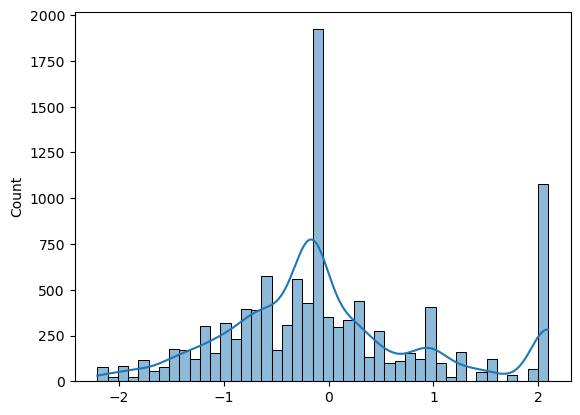

In [9]:
zscore=dsf.stdNBgraph(dataset["LoanAmount"])

In [10]:
## Calling this function to get the frequency Table for the input Column
## ['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term']
freqTable=dsf.freqTable(dataset,"ApplicantIncome")

In [11]:
freqTable

,Unique_Values,Frequency,RelativeFrequency,CumSum
0,8499.5,1337,12.980583,12.980583
1,3887.0,1279,12.417476,25.398058
2,5000.0,157,1.524272,26.922330
3,3500.0,139,1.349515,28.271845
4,3333.0,121,1.174757,29.446602
...,...,...,...,...
281,2539.0,17,0.165049,106.611650
282,4960.0,16,0.155340,106.766990
283,3268.0,16,0.155340,106.922330
284,3835.0,15,0.145631,107.067961


#### What are the most common loan amount ranges?

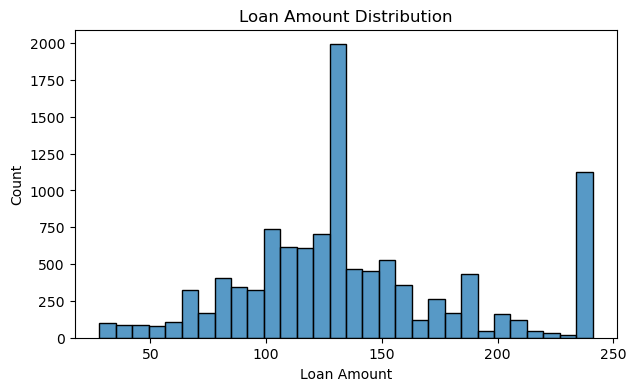

In [12]:
## Using histogram to plot it 

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(7,4))
sns.histplot(dataset['LoanAmount'], bins=30, kde=False)
plt.title("Loan Amount Distribution")
plt.xlabel("Loan Amount")
plt.ylabel("Count")
plt.show()

#### What percentage of applicants are Male vs Female?

In [13]:
gender_mode = dataset.loc[dataset['Gender'] != 'Unknown', 'Gender'].mode()[0]
dataset.loc[dataset['Gender'] == 'Unknown', 'Gender'] = gender_mode

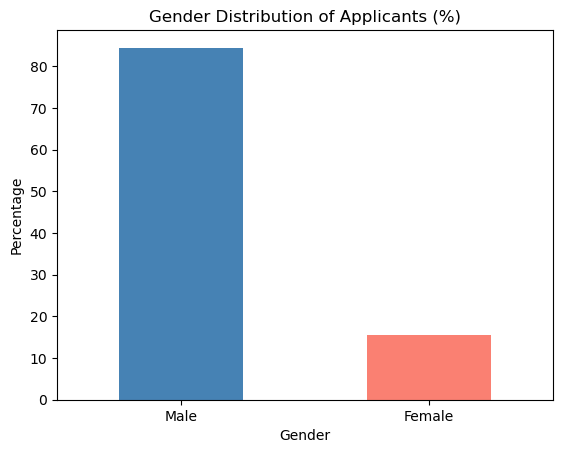

In [14]:
gender_percentage = (dataset['Gender'].value_counts(normalize=True) * 100)
import matplotlib.pyplot as plt

gender_percentage.plot(kind='bar', color=['steelblue', 'salmon'])
plt.title("Gender Distribution of Applicants (%)")
plt.ylabel("Percentage")
plt.xlabel("Gender")
plt.xticks(rotation=0)
plt.show()

### BiVariate Analysis

#### How does ApplicantIncome vary by Gender?

In [15]:
dataset.groupby('Gender')['ApplicantIncome'].describe()

,count,mean,std,min,25%,50%,75%,max
Gender,,,,,,,,
Female,1712.0,4223.633470,2073.232438,0.0,2779.0,3854.0,4742.0,8499.5
Male,9328.0,4458.076973,2042.503705,0.0,3074.0,3887.0,5316.0,8499.5


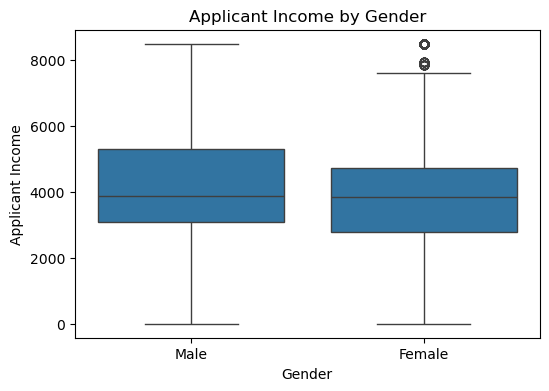

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
sns.boxplot(x='Gender', y='ApplicantIncome', data=dataset)
plt.title("Applicant Income by Gender")
plt.xlabel("Gender")
plt.ylabel("Applicant Income")
plt.show()

In [17]:
# Bivariate analysis using boxplots shows that ApplicantIncome distributions for Male and Female applicants are similar.
# Male applicants have a slightly higher median income, but the difference is not substantial. 

#### How does ApplicantIncome vary with LoanAmount?

In [18]:
## Used correlation analysis
dataset[['ApplicantIncome', 'LoanAmount']].corr()

,ApplicantIncome,LoanAmount
ApplicantIncome,1.000000,0.292733
LoanAmount,0.292733,1.000000


In [19]:
## This shows slightly positive correlation of 0.29

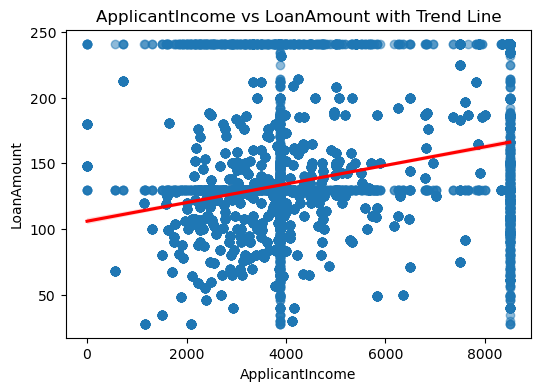

In [20]:
## Plotting in a graph Scatter Plot with Regression Line
plt.figure(figsize=(6,4))
sns.regplot(
    x='ApplicantIncome',
    y='LoanAmount',
    data=dataset,
    scatter_kws={'alpha':0.5},
    line_kws={'color':'red'}
)
plt.title("ApplicantIncome vs LoanAmount with Trend Line")
plt.show()

#### Do ApplicantIncome and LoanAmount move together ?

In [21]:
## Used covariance to find the relationship
dataset['ApplicantIncome'].cov(dataset['LoanAmount']).item()

29698.008298681805

In [22]:
### The positive covariance value confirms that ApplicantIncome and LoanAmount increase together

####  Are higher total incomes (Applicant + Coapplicant) associated with higher LoanAmount

In [23]:
## Used Multicolinearity
dataset['TotalIncome'] = (dataset['ApplicantIncome'] + dataset['CoapplicantIncome'])

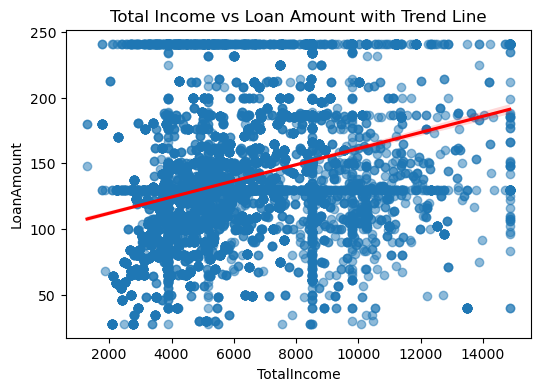

In [24]:
## Used Scatter plot to verify

plt.figure(figsize=(6,4))
sns.regplot(
    x='TotalIncome',
    y='LoanAmount',
    data=dataset,
    scatter_kws={'alpha':0.5},
    line_kws={'color':'red'}
)
plt.title("Total Income vs Loan Amount with Trend Line")
plt.show()

In [25]:
## This confirms that higher Income results to higher loan amount

#### Is the spread of LoanAmount similar for low‑income and high‑income applicants

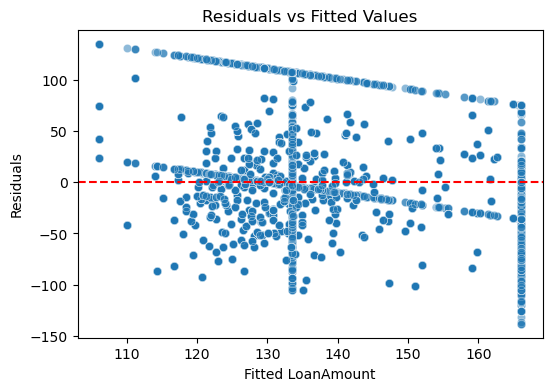

In [26]:
## Used plots to identify
import numpy as np

import statsmodels.api as sm

X = sm.add_constant(dataset['ApplicantIncome'])
y = dataset['LoanAmount']

model = sm.OLS(y, X).fit()

fitted = model.fittedvalues
residuals = model.resid

plt.figure(figsize=(6,4))
sns.scatterplot(x=fitted, y=residuals, alpha=0.5)
plt.axhline(0, color='red', linestyle='--')
plt.title("Residuals vs Fitted Values")
plt.xlabel("Fitted LoanAmount")
plt.ylabel("Residuals")
plt.show()

In [27]:
### the spread of loan amounts is larger for higher‑income applicants than for lower‑income applicants

#### Is there a significant difference in LoanAmount between Married and Unmarried applicants?

In [28]:
## Used T test to idenfy

from scipy.stats import ttest_ind

loan_married = dataset[dataset['Married'] == 'Yes']['LoanAmount']
loan_unmarried = dataset[dataset['Married'] == 'No']['LoanAmount']

t_test, p_value = ttest_ind(loan_married,loan_unmarried,equal_var=False)

print(t_test.item())
print(p_value.item())

11.387966362217874
8.759408048260182e-30


In [29]:
## From the above pvalue <0.5 which means Married applicants tend to request or receive higher loan amounts 

####  Is there a significant difference in LoanAmount between applicants with and without co‑applicants

In [30]:
## Identify using Hypothesis testing


## Ho = There is no difference in mean LoanAmount between applicants with and without co‑applicants.
## There is a significant difference in mean LoanAmount between applicants with and without co‑applicants

loan_with_coapp = dataset[dataset['CoapplicantIncome'] > 0]['LoanAmount']
loan_without_coapp = dataset[dataset['CoapplicantIncome'] == 0]['LoanAmount']

t_test, p_value = ttest_ind(loan_with_coapp,loan_without_coapp,equal_var=False)
print(t_test.item())
print(p_value.item())

7.146579789533832
9.779410693899038e-13


In [31]:
## The p‑value is < 0.05, we reject the null hypothesis 
# Conclude that LoanAmount differs significantly between applicants with and without co‑applicants
## Proceed with Alternative hypothesis

#### Does LoanAmount differ across Property_Area (Urban, Semiurban, Rural)?

In [32]:
### Used One way Anova Test

# H₀ = Yes,The mean LoanAmount is the same across all Property_Area categories
# H₁ = No, At least one Property_Area has a different mean LoanAmount.

urban = dataset[dataset['Property_Area'] == 'Urban']['LoanAmount']
semiurban = dataset[dataset['Property_Area'] == 'Semiurban']['LoanAmount']
rural = dataset[dataset['Property_Area'] == 'Rural']['LoanAmount']

from scipy.stats import f_oneway

f_stat, p_value = f_oneway(urban, semiurban, rural)

print(f_stat.item())
print(p_value.item())

15.091015978081758
2.8561632870064576e-07


In [33]:
## the p‑value is < 0.05, we reject the null hypothesis 
## Conclude that LoanAmount differs significantly across Property_Area categories